# Solving the Krusell-Smith model in sequence space
In this notebook we show how to
1. [Set up a heterogeneous-agent block](#1-hetblock)
2. [Calibrate a model numerically](#2-calibration)
3. [Compute the Jacobian "by hand" as well as automatically](#3-jacobian)
4. [Compute linearized impulse responses](#4-linear)
5. [Estimate shock parameters](#5-estimate)
6. [Compute nonlinear impulse responses](#6-nonlinear)

This notebook accompanies the working paper Auclert, Bardóczy, Rognlie, Straub (2019): "Using the Sequence-Space Jacobian to Solve and Estimate Heterogeneous-Agent Models". Please see the [Github repository](https://github.com/shade-econ/sequence-jacobian) for more information and code.

## Model description
For a detailed description of the model, please see the paper. As a quick reminder, it can be written in sequence space as

$$
\textbf{H}_t(\textbf{U}, Z) \equiv 
\begin{pmatrix}
%Y_t - Z_t K_t^\alpha L^{1-\alpha}
%\\
r_t + \delta - \alpha Z_t \left(\frac{K_{t-1}}{L_t}\right)^{\alpha-1} 
\\
w_t - (1-\alpha) Z_t \left(\frac{K_{t-1}}{L_t}\right)^{\alpha}
\\
L_t - \sum_e \pi(e) e
\\
\mathcal{K}_t(\{r_s, w_s\}) - K_t
\end{pmatrix}
= \begin{pmatrix}  0 \\ 0 \\ 0 \\ 0\end{pmatrix},
\qquad t = 0, 1, \dots
$$

where the (aggregate) endogenous variables are $\textbf{U} = (K, L, r, w)$ and the only exogenous variable is $Z$. Let's normalize $\sum_e \pi(e) e = 1$ without loss of generality.

The capital function $\mathcal{K}$ follows from the household block characterized by a Bellman equation

$$
\begin{align}
V_t(e, k_{-}) = \max_{c, k} &\left\{\frac{c^{1-\sigma}}{1-\sigma} + \beta \sum_{e'}V_{t+1}(e', k) \mathcal{P}(e, e') \right\}
\\
c + k &= (1 + r_t)k_{-} + w e 
\\
k &\geq 0
\end{align}
$$

We can represent this model as a simple Directed Acyclic Graph in just 1 unknown $K$ and 1 target, asset market clearing:

![Directed Acyclical Graph](../figures/ks_dag.png) 

and write it as

$$
H_t(K, Z) \equiv \mathcal{K}_t\left(\left\{\alpha Z_s K_{s-1}^{\alpha-1} - \delta, (1-\alpha) Z_s K_{s-1}^{\alpha}\right\}\right) - K_t = 0.
$$

## 0 Import packages
The first five are standard python packages, the rest contain code we wrote for this project. 

In [1]:
# Add the relative path to the top-level of the "sequence-jacobian" folder
# to be able to access the sequence_jacobian module
import sys
sys.path.append("..")

import numpy as np
from numba import njit
import scipy.optimize as opt
import scipy.linalg as linalg
import matplotlib.pyplot as plt

import sequence_jacobian as sj
from sequence_jacobian import simple, het

<a id="1-hetblock"></a>

## 1 Set up heterogeneous-agent block
The main task here is to write a **backward iteration function** that represents the Bellman equation. This has to be a single step of an iterative solution method such as value function iteration that solves for optimal policy on a grid. For the standard income fluctuation problem we're dealing with here, the endogenous gridpoint method of [Carroll (2006)](https://www.sciencedirect.com/science/article/pii/S0165176505003368) is the best practice. 

Once we have the backward iteration function, we can use the decorator `@het` to turn it into a HetBlock. All we have to do is specify the transition matrix for exogenous states `exogenous`, the policy corresponding to the endogenous state(s) `policy` (currently up to two states), and the backward variable `backward` on which we're iterating (here the first derivative `Va` of the value function with respect to assets).

In [2]:
@het(exogenous='Pi', policy='a', backward='Va')
def household(Va_p, Pi_p, a_grid, e_grid, r, w, beta, eis):
    """Single backward iteration step using endogenous gridpoint method for households with CRRA utility.

    Parameters
    ----------
    Va_p     : array (S*A), marginal value of assets tomorrow
    Pi_p     : array (S*S), Markov matrix for skills tomorrow
    a_grid   : array (A), asset grid
    e_grid   : array (A), skill grid
    r        : scalar, ex-post real interest rate
    w        : scalar, wage
    beta     : scalar, discount rate today
    eis      : scalar, elasticity of intertemporal substitution

    Returns
    ----------
    Va : array (S*A), marginal value of assets today
    a  : array (S*A), asset policy today
    c  : array (S*A), consumption policy today
    """
    uc_nextgrid = (beta * Pi_p) @ Va_p
    c_nextgrid = uc_nextgrid ** (-eis)
    coh = (1 + r) * a_grid[np.newaxis, :] + w * e_grid[:, np.newaxis]
    a = sj.utilities.interpolate.interpolate_y(c_nextgrid + a_grid, coh, a_grid)
    sj.utilities.optimized_routines.setmin(a, a_grid[0])
    c = coh - a
    Va = (1 + r) * c ** (-1 / eis)
    return Va, a, c

In [3]:
print(type(household))
household.__dict__

<class 'sequence_jacobian.blocks.het_block.HetBlock'>


{'back_step_fun': <function __main__.household(Va_p, Pi_p, a_grid, e_grid, r, w, beta, eis)>,
 'back_step_output_list': ['Va', 'a', 'c'],
 'back_step_outputs': {'Va', 'a', 'c'},
 'back_step_inputs': {'Pi_p',
  'Va_p',
  'a_grid',
  'beta',
  'e_grid',
  'eis',
  'r',
  'w'},
 'exogenous': 'Pi',
 'policy': ('a',),
 'back_iter_vars': ('Va',),
 'inputs_to_be_primed': {'Pi', 'Va'},
 'non_back_iter_outputs': {'a', 'c'},
 'outputs': {'A', 'C'},
 'inputs': {'Pi', 'a_grid', 'beta', 'e_grid', 'eis', 'r', 'w'},
 'hetinput': None,
 'hetinput_inputs': set(),
 'hetinput_outputs': set(),
 'hetinput_outputs_order': (),
 'hetoutput': None,
 'hetoutput_inputs': set(),
 'hetoutput_outputs': set(),
 'hetoutput_outputs_order': (),
 'backward_init': None,
 'saved': {},
 'prelim_saved': {},
 'saved_shock_list': [],
 'saved_output_list': []}

As its name suggests, HetBlock is a general class of heterogeneous-agent blocks that comes with useful methods, such as solving for steady-state policy functions by iteration, updating the distribution of agents across states using these policy rules interpolated against a grid, and computing/storing Jacobians. We are going to cover the the most important methods in this notebook.

<a id="2-calibration"></a>

## 2 Calibrating the steady state
Next, we calibrate the model in general equilibrium. The calibration exercise amounts to finding the right discount factor $\beta$ to hit a targeted interest rate conditional on all the other exogenous parameters. We use Brent's method, an efficient way to solve for a root on an interval, from the `scipy.optimize` package to do so.

Although additional efficiency gains would be possible here (for instance, by updating our initial guesses for policy and distribution along the way), we will not implement them, since they are not our focus here.

Our default values depart slightly from the canonical Krusell-Smith calibration, mainly by assuming a 7-state income process and a lower capital share. More risk increases the precautionary savings motive, while less capital limits the ability to self-insure. These changes lead to higher MPCs and less RA-like behavior.

In [4]:
def ks_ss(lb=0.98, ub=0.999, r=0.01, eis=1, delta=0.025, alpha=0.11, rho=0.966, sigma=0.5, nS=7, nA=500, amax=200):
    """Solve steady state of full GE model. Calibrate beta to hit target for interest rate.
    
    Parameters
    ----------
    lb    : scalar, lower bound of interval bracketing beta
    ub    : scalar, upper bound of interval bracketing beta
    r     : scalar, real interest rate
    eis   : scalar, elasticity of intertemporal substitution
    delta : scalar, depreciation rate
    alpha : scalar, capital share
    rho   : scalar, autocorrelation of income process
    sigma : scalar, cross-sectional sd of log income
    nS    : int, number of income gridpoints
    nA    : int, number of capital gridpoints
    amax  : scalar, upper bound of capital grid

    Returns
    ----------
    ss : dict, steady state values
    """
    # set up grid
    a_grid = sj.utilities.discretize.agrid(amax=amax, n=nA)
    e_grid, pi_s, Pi = sj.utilities.discretize.markov_rouwenhorst(rho=rho, sigma=sigma, N=nS)
    
    # solve analytically what we can
    rk = r + delta
    Z = (rk / alpha) ** alpha  # normalize so that Y=1
    K = (alpha * Z / rk) ** (1 / (1 - alpha))
    Y = Z * K ** alpha
    w = (1 - alpha) * Z * (alpha * Z / rk) ** (alpha / (1 - alpha))
    
    # initialize guess for policy function iteration
    coh = (1 + r) * a_grid[np.newaxis, :] + w * e_grid[:, np.newaxis]
    Va = (1 + r) * (0.1 * coh) ** (-1 / eis)

    # solve for beta
    beta_min = lb / (1 + r)
    beta_max = ub / (1 + r)
    beta, sol = opt.brentq(lambda bet: household.ss(Pi=Pi, a_grid=a_grid, e_grid=e_grid, r=r, w=w, beta=bet, eis=eis,
                                                    Va=Va)['A'] - K, beta_min, beta_max, full_output=True)
    if not sol.converged:
        raise ValueError('Steady-state solver did not converge.')

    # extra evaluation for reporting
    ss = household.ss(Pi=Pi, a_grid=a_grid, e_grid=e_grid, r=r, w=w, beta=beta, eis=eis, Va=Va)
    
    # check Walras's law
    walras = Y - ss['C'] - delta * K
    assert np.abs(walras) < 1E-8
    
    # add aggregate variables
    ss.update({'w': w, 'Z': Z, 'K': K, 'L': 1, 'Y': Y, 'alpha': alpha, 'delta': delta, 'walras': walras})

    return ss

Notice the use of `household.ss` to evaluate steady-state asset demand for given inputs. This is the first HetBlock method we see in action.

Let's solve for the steady state using our default calibration, and plot the consumption policy function for all skill types  as a function of assets.

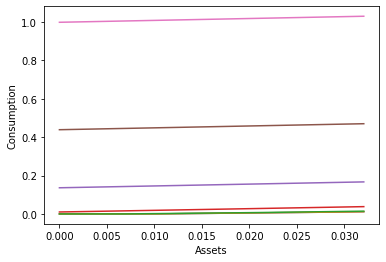

In [5]:
ss = ks_ss()
plt.plot(ss['a_grid'][:10], ss['a'][:, :10].T)
plt.xlabel('Assets'), plt.ylabel('Consumption')
plt.show()

### Speed of steady-state solution
Our backward and forward iterations use Numba, [a just-in-time compilation library](https://numba.pydata.org/numba-doc/dev/user/5minguide.html) that translates pure numerical Python to fast machine code. The first time functions are run, there is some compilation lag, similar to (but much less time-consuming than) compilation time in languages like C++, Fortran, and Julia.

Now that we have run everything once, we can time our steady-state calibration routine. An efficient steady state is not the focus of this notebook or our methods, but it is nice to see that performance is still quite good:

In [6]:
%time ss = sj.krusell_smith.ks_ss()

CPU times: user 596 ms, sys: 8.18 ms, total: 605 ms
Wall time: 608 ms


Indeed, this simple example is so fast that increasing the number of asset gridpoints from 500 to 2000, and thus the total number of states from $7 \times 500=3500$ to $7 \times 2000 = 14000,$ increases computation time by less than a factor of four.

In [7]:
%time _ = sj.krusell_smith.ks_ss(nA=2000)

CPU times: user 7.19 s, sys: 223 ms, total: 7.41 s
Wall time: 2.39 s


<a id="3-jacobian"></a>

## 3 Jacobians
Jacobians are the key concept to solve and to estimate models in sequence space. Each model block has its own Jacobians, which can be combined via the chain rule into Jacobians for the complete model. A Jacobian in a $T$-dimensional (truncated) sequence space is a $T \times T$ matrix of the form

$$
\frac{d Y}{d X} = 
\begin{pmatrix}
\frac{d Y_0}{d X_0} & \frac{d Y_0}{d X_1} & \dots & \frac{d Y_0}{d X_T} \\
\vdots & \vdots & \ddots & \vdots \\
\frac{d Y_T}{d X_0} & \frac{d Y_T}{d X_1} & \dots & \frac{d Y_T}{d X_T}
\end{pmatrix}
$$

evaluated at the steady state. Every column can be interpreted as the impulse response to a one-period news shock.

### 3.1 Simple blocks
To build intuition, let's start with the firm block. In our code, simple blocks are specified as regular Python functions with the added decorator ``@simple``. In the body of the function, we directly implement the corresponding equilibrium conditions. The decorator turns the function into an instance of ``SimpleBlock``, a class that, among other things, knows how to handle time displacements such as `K(-1)` to denote 1-period lags and `r(+1)` to denote 1-period leads. In general, one can write (-s) and (+s) to denote s-period lags and leads.

In [8]:
@simple
def firm(K, L, Z, alpha, delta):
    r = alpha * Z * (K(-1) / L) ** (alpha-1) - delta
    w = (1 - alpha) * Z * (K(-1) / L) ** alpha
    Y = Z * K(-1) ** alpha * L ** (1 - alpha)
    return r, w, Y

Simple blocks can compute their Jacobians by using the method `SimpleBlock.jac` This takes in the steady state dict returned by `ks_ss` and two optional inputs: the truncation horizon and list of variables to differentiate with respect to. It returns the Jacobians in a nested dict, where the first level is the output variable $Y$ and the second level is the input variable $X$.

In [9]:
J_firm = firm.jac(ss, T=5, shock_list=['K', 'Z'])
print(J_firm['Y']['Z']) # Jacobian of output Y vs. TFP Z
J_firm

[[1.13424196 0.         0.         0.         0.        ]
 [0.         1.13424196 0.         0.         0.        ]
 [0.         0.         1.13424196 0.         0.        ]
 [0.         0.         0.         1.13424196 0.        ]
 [0.         0.         0.         0.         1.13424196]]


{'r': {'Z': array([[0.03969847, 0.        , 0.        , 0.        , 0.        ],
         [0.        , 0.03969847, 0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.03969847, 0.        , 0.        ],
         [0.        , 0.        , 0.        , 0.03969847, 0.        ],
         [0.        , 0.        , 0.        , 0.        , 0.03969847]]),
  'K': array([[ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
         [-0.00991136,  0.        ,  0.        ,  0.        ,  0.        ],
         [ 0.        , -0.00991136,  0.        ,  0.        ,  0.        ],
         [ 0.        ,  0.        , -0.00991136,  0.        ,  0.        ],
         [ 0.        ,  0.        ,  0.        , -0.00991136,  0.        ]])},
 'w': {'Z': array([[1.00947535, 0.        , 0.        , 0.        , 0.        ],
         [0.        , 1.00947535, 0.        , 0.        , 0.        ],
         [0.        , 0.        , 1.00947535, 0.        , 0.        ],
         [0.        , 

By default, `SimpleBlock.jac` compoutes the Jacobian for each input-output pair. In practice, it only makes sense to do so with respect to endogenous variables and shocks, hence the `shock_list` option. In this model, capital and TFP are the only inputs that will ever change.

The Jacobian is diagonal because the production function does not depend on leads or lags of productivity. Such sparsity is very common for simple blocks, and we wrote the SimpleBlock class to take full advantage of it. For example, if we leave the truncation parameter $T$ unspecified, which is recommended, `SimpleBlock.jac` returns a more efficient sparse representation of the Jacobian.

In [10]:
J_firm_sparse = firm.jac(ss, shock_list=['K', 'Z'])
print(J_firm_sparse['Y']['Z'])

SimpleSparse({(0, 0): 1.134})


The output means that the only non-zero element is 1.134 along the main diagonal.

### 3.2 HA blocks
HA blocks have more complicated Jacobians, but they have a regular structure that we can exploit to calculate them very quickly. For comprehensive coverage of our **fake news algorithm**, please see the [het-agent Jacobian notebook](het_jacobian.ipynb) as well as the paper.

HetBlocks have a `HetBlock.jac` method that is analogous to `SimpleBlock.jac` above.

In [11]:
J_ha = household.jac(ss, T=5, shock_list=['r', 'w'])
print(J_ha['C']['r'])

[[ 0.09578534 -0.68179015 -0.64119935 -0.60434415 -0.57057436]
 [ 0.09413756  0.13463153 -0.64841526 -0.61133486 -0.5771951 ]
 [ 0.09250592  0.12963223  0.16651935 -0.61980277 -0.58527967]
 [ 0.09087539  0.12509918  0.15952962  0.1938437  -0.59485549]
 [ 0.08926245  0.12116257  0.15312513  0.18541035  0.21770361]]


Notice that this matrix is no longer sparse. This generally the case for HA blocks. The Bellman equation implies that policies are forward-looking, and then aggregates are also backward-looking due to persistence coming via the distribution.

Fortunately, our `SimpleSparse` Jacobians play nicely with these full matrices, so that we can easily combine the Jacobians of simple blocks and HA blocks. For example, the multiplication operator `@` maps any combination of SimpleSparse and full matrices into full matrices.   

In [12]:
print(J_ha['C']['r'] @ J_firm_sparse['r']['Z'])

[[ 0.00380253 -0.02706602 -0.02545463 -0.02399154 -0.02265093]
 [ 0.00373712  0.00534467 -0.02574109 -0.02426906 -0.02291376]
 [ 0.00367234  0.0051462   0.00661056 -0.02460522 -0.02323471]
 [ 0.00360761  0.00496625  0.00633308  0.0076953  -0.02361485]
 [ 0.00354358  0.00480997  0.00607883  0.00736051  0.0086425 ]]


<a id="4-linear"></a>

## 4 Linearized dynamics using Jacobians
Recall that we reduced the model to a single equation $H$

$$
H_t(K, Z) \equiv \mathcal{K}_t\left(\left\{\alpha Z_s K_{s-1}^{\alpha-1} - \delta, (1-\alpha) Z_s K_{s-1}^{\alpha}\right\}\right) - K_t = 0.
$$

to be solved for $K$ given any $Z$.

This is the composition of the household capital supply function $\mathcal{K}$ with the interest rate $r(K_{t-1}, Z_t) = \alpha Z_t K_{t-1}^{\alpha-1} - \delta$ and wage $w(K_{t-1}, Z_t) = (1-\alpha) Z_t K_{t-1}^{\alpha}$ functions.

We will obtain a linear characterization of all impulse responses in two ways:
- First, by duly following the notation and algebra of section 2.2 in the paper. This hands-on approach is transparent, but error-prone in all but the simplest cases.
- Second, by leveraging the powerful convenience functions that we introduced in the RBC notebook, and further employ in the one-asset and two-asset HANK notebooks. Throughout this section, we'll use the steady state `ss` we've already solved for, and a 300-period truncation horizon.

### 4.1 Hands-on approach

##### Step 1: For each block, obtain Jacobians of outputs with respect to inputs
Here, we only have two blocks: the firm and household blocks. Getting these Jacobians is quite quick, even for the HA block.

In [13]:
# firm Jacobian: r and w as functions of K and Z
J_firm = firm.jac(ss, shock_list=['K', 'Z'])

# household Jacobian: curlyK (called 'a' for assets by J_ha) as function of r and w
T = 300
J_ha = household.jac(ss, T=T, shock_list=['r', 'w'])

#### Step 2: Compose Jacobians along the computational graph
Here, we manually apply the chain rule to calculate the total Jacobians of household $\mathcal{K}$ with respect to $K$ and $Z$, by composing the partial Jacobians `J_ha` (which maps $r$ and $w$ to $\mathcal{K}$) and `J_firm` (which maps $K$ and $Z$ to $r$, $w$, and $Y$).

In [14]:
J_curlyK_K = J_ha['A']['r'] @ J_firm['r']['K'] + J_ha['A']['w'] @ J_firm['w']['K']
J_curlyK_Z = J_ha['A']['r'] @ J_firm['r']['Z'] + J_ha['A']['w'] @ J_firm['w']['Z']

Now, we will combine `J_curlyK_K` and `J_curlyK_Z` with the firm Jacobians to get a single nested dict with the total Jacobians of everything with respect to $K$ and $Z$:

In [15]:
J = {**J_firm, 'curlyK': {'K' : J_curlyK_K, 'Z' : J_curlyK_Z}}

#### Step 3: Invert $H_K$ to obtain impulse response $dK=-H_K^{-1}H_ZdZ$
Now we need to get the Jacobians of our equation $H(K,Z)$, which fully characterizes equilibrium, with respect to $K$ and $Z$. Once we have these, the implicit function theorem gives us the endogenous capital $dK=-H_K^{-1}H_ZdZ$ response to any exogenous shock $dZ$.

Recall that $H$ equals household capital supply $\mathcal{K}$ minus firm capital $K$, so that we can get the Jacobians almost immediately from what we have already calculated.

In [16]:
H_K = J['curlyK']['K'] - np.eye(T)
H_Z = J['curlyK']['Z']

We define $G_K \equiv -H_K^{-1}H_Z$ to be the matrix mapping from any $dZ$ to the corresponding $dK$:

In [17]:
G = {'K': -np.linalg.solve(H_K, H_Z)} # H_K^(-1)H_Z

#### Step 4: Get all other impulses
In `J`, we have Jacobians of $r,w,Y$ with respect to both $Z$ and $K$. If there is a shock to $Z$, we can decompose the change in $r,w,Y$ into a "direct" effect from $dZ$ and an "indirect" effect from the induced change $dK$.

We apply the chain rule to the latter to get matrices $G_r, G_w, G_Y$ mapping any $dZ$ to the corresponding $dr,dw,dY$:

In [18]:
G['r'] = J['r']['Z'] + J['r']['K'] @ G['K']
G['w'] = J['w']['Z'] + J['w']['K'] @ G['K']
G['Y'] = J['Y']['Z'] + J['Y']['K'] @ G['K']

The `G` dict characterizes the full linearized dynamics of aggregate variables $K, r, w, Y$ in response to *any* perturbation to $Z$.

If we want the linearized dynamics of other variables, e.g. consumption, all we need is to get the Jacobian from the block in which these are calculated, and then compose it with the `G` of its inputs. It turns out that consumption was already reported in `J_ha`, so we just need to write:

In [19]:
G['C'] = J_ha['C']['r'] @ G['r'] + J_ha['C']['w'] @ G['w']

### 4.2 Convenient approach

These steps can be automatized for the entire class of SHADE models. Any SHADE model is characterized by its blocks, exogenous shocks, unknowns, and targets. The only other things we need to know are the steady state around which to linearize, and the truncation horizon.

If we define a "market clearing" block that returns the target (asset market clearing), we can get the general equilibrium Jacobians by simply calling `jacobian.get_G`. Note that `get_G` takes in the model blocks (in arbitrary order), the names of exogenous shocks, the names of unknown endogenous variables, the names of target equations, the truncation horizon, and the steady state dict.

In [20]:
@simple
def mkt_clearing(K, A):
    asset_mkt = A - K
    return asset_mkt

In [21]:
G2 = sj.jacobian.get_G(block_list=[firm, mkt_clearing, household],  # we could replace household with J_ha here
                       exogenous=['Z'],
                       unknowns=['K'],
                       targets=['asset_mkt'],
                       T=T, ss=ss)
G2

{'r': {'Z': array([[ 3.96984687e-02,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [-9.15346746e-03,  4.03513232e-02,  5.72174702e-04, ...,
           2.97841996e-14,  1.93204235e-14,  8.10423095e-15],
         [-8.26684569e-03, -8.59423334e-03,  4.08558171e-02, ...,
           5.67514164e-14,  3.75650196e-14,  1.57401193e-14],
         ...,
         [-5.20286295e-11, -4.96763298e-11, -4.76007645e-11, ...,
           4.11904992e-02,  9.77703672e-04,  4.83595938e-04],
         [-5.13498354e-11, -4.91271932e-11, -4.71746697e-11, ...,
          -8.22085352e-03,  4.08157275e-02,  5.65594849e-04],
         [-5.09479849e-11, -4.88376123e-11, -4.69923641e-11, ...,
          -7.85503499e-03, -8.63760381e-03,  4.03574579e-02]])},
 'K': {'Z': array([[ 9.23532603e-01, -6.58692964e-02, -5.77291605e-02, ...,
          -3.00505569e-12, -1.94932042e-12, -8.17670630e-13],
         [ 8.34077529e-01,  8.67109073e-01, -1.16769844e-01, ...,
 

Let's verify that the two give the same answer up to high precision (`assert` throws an error if its argument evaluates to False).

In [22]:
for o in G:
    assert np.allclose(G2[o]['Z'], G[o])

### 4.2 Results
What do the impulse responses in this model look like? The beauty of our method is that, now that we have $G$, we can compute impulse responses to any shock almost instantaneously -- it's just matrix multiplication!

Let's first consider shocks to $Z$ with different persistences, all normalized so that they have a 1% initial impact, and plot the interest rate response to each.

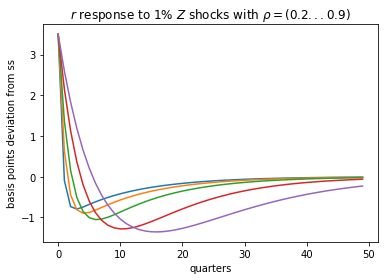

In [23]:
rhos = np.array([0.2, 0.4, 0.6, 0.8, 0.9])
dZ = 0.01*ss['Z']*rhos**(np.arange(T)[:, np.newaxis]) # get T*5 matrix of dZ
dr = G['r'] @ dZ
plt.plot(10000*dr[:50, :])
plt.title(r'$r$ response to 1% $Z$ shocks with $\rho=(0.2 ... 0.9)$')
plt.ylabel(r'basis points deviation from ss')
plt.xlabel(r'quarters')
plt.show()

Now let's consider 10,000 different values of rho, for which we can still calculate all $r$ impulse responses almost instantaneously.

In [24]:
rhos = np.linspace(0.1, 0.9, 10000)
dZ = 0.01*ss['Z']*rhos**(np.arange(T)[:, np.newaxis]) # get T*5 matrix of dZ
%time dr = G['r'] @ dZ

CPU times: user 66.7 ms, sys: 16 ms, total: 82.7 ms
Wall time: 21.9 ms


The time taken here differs from run to run, but in the current run (like all runs on a personal laptop) it takes less than 50 milliseconds of "wall time" to compute 10,000 impulse responses means that each impulse response takes less than **5 microseconds**. "CPU time" is slightly higher because mild parallelization on two cores is used by the built-in matrix multiplication implementation. By contrast, typical impulse response calculations in heterogeneous agent models in the literature take at least a minute, so this method is more than **10 million** times faster as a way of calculating individual impulse responses.

Although this may seem like an extreme example, repeated calculations of this form are quite useful in the most computationally demanding applications, like estimation (as we will see later).

Another important feature of our sequence space methodology is that it is easy to calculate the response to shocks that are difficult to cast into simple recursive form, like news shocks.

For example, calculating the response to a news shock where $Z$ is expected to increase at a specific period in the future is trivial -- in fact, that's exactly what the columns of the $G$ matrix are. Below we plot the capital responses to news shocks of $Z$ increases at periods 5, 10, 15, 20, and 25.

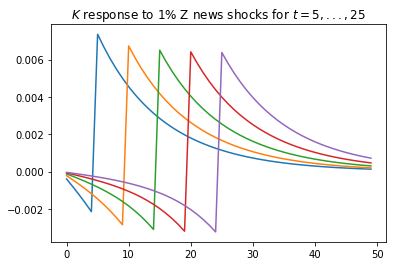

In [25]:
dZ = 0.01*(np.arange(T)[:, np.newaxis] == np.array([5, 10, 15, 20, 25]))
dK = G['K'] @ dZ
plt.plot(dK[:50])
plt.title('$K$ response to 1% Z news shocks for $t=5,...,25$')
plt.show()

<a id="5-estimate"></a>

## 5 Estimation

The roadmap for estimation is as follows:
 - impulse responses $\implies$ second moments
 - second moments $\implies$ log-likelihood
 
In this notebook, we will simply use simulated data to show that the log-likelihood peaks close to the true value of the estimated parameter, the standard deviation of TFP shocks. 

### 5.1 Second moments 
Thanks to certainty equivalence, linear impulse responses can be interpreted as the $MA(\infty)$ representation of the model. Then all we need is the second moments of the shocks to fully characterize the second moments of endogenous outcomes. This computation can be done in a highly efficient way, without any need for simulation.

For concreteness, let's suppose that the TFP shocks $dZ$ in the Krusell-Smith model have a persistent and transitory component.

$$
\begin{align*}
dZ_t &= dZ^1_t + d Z_t^2
\\
dZ_t^1 &= \rho d Z_{t-1}^1 + \epsilon^1_t
\\
d Z_t^2 &= \epsilon^2_t
\end{align*}
$$

where $\epsilon^1$ and $\epsilon^2$ are i.i.d. normal with mean zero and with variance $\sigma^2_1$ and $\sigma^2_2$. 

Let $m^{x, 1}$ and $m^{x,2}$ denote the (truncated) impulse responses of variable $X$ to these two structural shocks. Then we have an $MA(T-1)$ representation:

$$
X_t = \sum_{z=1}^{2} \sum_{s=0}^{T-1} m^{x,z}_s \epsilon_{t-s}^z 
$$

It follows that covariances between outcomes $Y$ and $X$ take the form

$$
\text{Cov}(Y_t, X_{t+l})= \sum_{z=1}^{2} \sigma_z^2 \sum_{s=0}^{T-1} m_s^{x,z} m_{s+l}^{y,z} \tag{Cov}
$$

#### Step 1. Stacked impulse responses

Given the $G$ matrix we calculated in section 4, this is just a matter of matrix multiplication

Our goal is to build $d\mathbf{X}_{s} = [d\mathbf{X}^{o,z}]$ with all the IRFs. We stack the IRFs for all outcomes given each shock in $dX_z$, a $T,4$ matrix with the IRFs in each column of the shock $Z_z$ and all endogenous variables, $3$ here.

Persistent shock -> Y,C,K


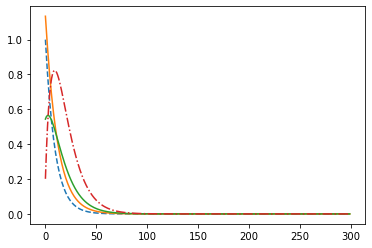

Temporary shock -> Y,C,K


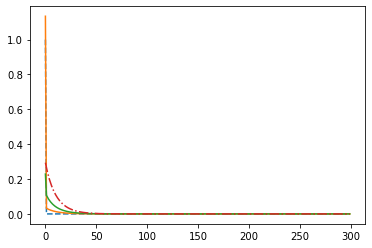

(300, 4)


In [26]:
rho = 0.9
sigma_persist = 0.1
sigma_trans = 0.2

dZ1 = rho**(np.arange(T)) ## Persistent shock
dY1, dC1, dK1 = G['Y'] @ dZ1, G['C'] @ dZ1, G['K'] @ dZ1
dX1 = np.stack([dZ1, dY1, dC1, dK1], axis=1)

dZ2 = np.arange(T) == 0 ## Transitory one-time shock
dY2, dC2, dK2 = G['Y'] @ dZ2, G['C'] @ dZ2, G['K'] @ dZ2
dX2 = np.stack([dZ2, dY2, dC2, dK2], axis=1)

print('Persistent shock -> Y,C,K')
plt.plot(dZ1,'--')
plt.plot(dY1/ss['Y'])
plt.plot(dC1/ss['C'])
plt.plot(dK1/ss['K'],'-.')
plt.show()
print('Temporary shock -> Y,C,K')
plt.plot(dZ2,'--')
plt.plot(dY2/ss['Y'])
plt.plot(dC2/ss['C'])
plt.plot(dK2/ss['K'],'-.')
plt.show()

print(dX2.shape)


To get $d\mathbf{X}_{s} = [d\mathbf{X}^{o,z}]$ with all outputs and shocks, let's stack all these to make a $T\times 4 \times 2$ array giving all impulse responses of the four outcomes to the two shocks:

In [27]:
dX = np.stack([dX1, dX2], axis=2)
dX.shape

(300, 4, 2)

#### Step 2. Obtain covariance at all leads and lags

The covariance formula above is implemented efficiently using the Fast Fourier Transform by the `all_covariances` function, which returns a $T\times 4\times 4$ array `Sigma`, where `Sigma[l, o1, o2]` gives the covariance for any $t$ between output `o1` at $t$ and output `o2` at $t+l$.

In case you get confused, I am comparing here the paper's notation with the one in this notebook
$$
X_t = \sum_{z=1}^{2} \sum_{s=0}^{T-1} m^{x,z}_s \epsilon_{t-s}^z ,\quad d\tilde{X}_{t}^{o}=\sum_{s=0}^{T-1}\sum_{z\in\mathcal{Z}}dX_{s}^{o,z}\epsilon_{t-s}^{z}
$$

$$m^{x,z} = \mathbf{G}^{x,z}d\mathbf{Z}^{z} ,\quad d\mathbf{X}^{o,z}=\mathbf{G}^{o,z}d\mathbf{Z}^{z}$$ 


It follows that covariances between outcomes $Y$ and $X$ take the form

$$
\Sigma_{T\times n_o \times n_o} = \text{Cov}(Y_t, X_{t+l})= \sum_{z=1}^{2} \sigma_z^2 \sum_{s=0}^{T-1} m_s^{x,z} m_{s+l}^{y,z} \tag{Cov},\quad \operatorname{Cov}\left(d\tilde{\mathbf{X}}_{t},d\tilde{\mathbf{X}}_{t^{\prime}}\right)=\sum_{s=0}^{T-1-\left(t^{\prime}-t\right)}\left(d\mathbf{X}_{s}\right)\left(d\mathbf{X}_{s+t^{\prime}-t}\right)^{\prime}
$$

$$\mathbf{V}\leftarrow {Cov}\left(d\tilde{\mathbf{X}}_{t}^{obs},d\tilde{\mathbf{X}}_{t^{\prime}}^{obs}\right)=B\operatorname{Cov}\left(d\tilde{\mathbf{X}}_{t},d\tilde{\mathbf{X}}_{t^{\prime}}\right)B^{\prime}+1_{t=t^{\prime}}\cdot\Sigma_{\mathbf{u}}$$

Naturally $\mathbf {\theta}$ where ${\theta} = [\sigma_1 , \sigma_2,\rho]$ directly via the variances of the shocks, but might also indirectly via the IRFs $m(\theta)$ since the shock process affects agents decisions and their choices affect the response of aggregates to shocks. Keep in mind that $dZ_t \propto \rho^t$

Stacking the data $\mathbf{V},n_{obs}T_{obs}\times n_{obs}T_{obs}$ and $d\tilde{\mathbf{X}}^{obs}=\left(d\tilde{\mathbf{X}}_{t}^{obs}\right)$ as a $n_{obs}T_{obs}$ dimension vector



In [28]:
sigmas = np.array([sigma_persist, sigma_trans])
Sigma = sj.estimation.all_covariances(dX, sigmas) # burn-in for jit
%time Sigma = sj.estimation.all_covariances(dX, sigmas)
Sigma.shape

CPU times: user 424 µs, sys: 26 µs, total: 450 µs
Wall time: 441 µs


(300, 4, 4)

#### Visualizing correlations

Let's turn the covariance matrix `Sigma` into a **correlation matrix**, by normalizing it with the standard deviation of each series:

In [29]:
sd = np.sqrt(np.diag(Sigma[0, ...]))
sd


array([0.30435436, 0.36632369, 0.21387737, 1.20775147])

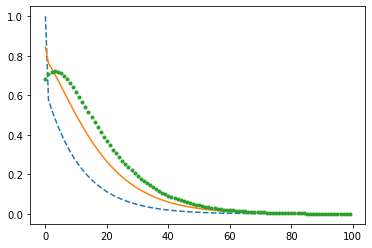

In [30]:
correl = (Sigma/sd)/(sd[:, np.newaxis])
correl.shape
plt.plot(correl[0:100,1,1],'--')
plt.plot(correl[0:100,1,2]) # Y and C
plt.plot(correl[0:100,1,3],'.') # Y and K

Finally, let's plot $\text{corr}(dZ_t,dZ_{t+l})$, $\text{corr}(dZ_t,dY_{t+l})$, $\text{corr}(dZ_t,dC_{t+l})$, and $\text{corr}(dZ_t,dK_{t+l})$, for $l$ from $-50$ through $50$: the correlations of all series, at various lags, with the driving productivity process.

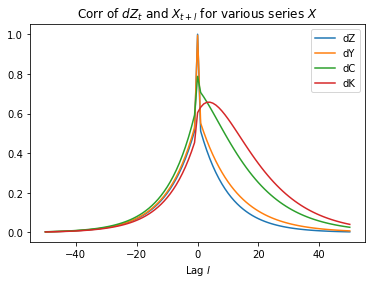

In [31]:
ls = np.arange(-50, 51)
corrs_l_positive = correl[:51, 0, :]
corrs_l_negative = correl[50:0:-1, :, 0]
corrs_combined = np.concatenate([corrs_l_negative, corrs_l_positive])

plt.plot(ls, corrs_combined[:, 0], label='dZ')
plt.plot(ls, corrs_combined[:, 1], label='dY')
plt.plot(ls, corrs_combined[:, 2], label='dC')
plt.plot(ls, corrs_combined[:, 3], label='dK')
plt.legend()
plt.title(r'Corr of $dZ_t$ and $X_{t+l}$ for various series $X$')
plt.xlabel(r'Lag $l$')
plt.show()

Here we can see many features of the solution. First, $dY$ is extremely similar to $dZ$, except that it has a greater lagged response due to capital accumulation. Both $dZ$ and $dY$ have a large peak at $l=0$ corresponding to the transitory shock. $dC$ and $dK$, on the other hand, are both much smoother and tend to lag $dZ$, especially $dK$.

### 5.2 Log-likelihood

Assuming the means of all series are zero (which is often imposed through some kind of preliminary demeaning or detrending procedure on the data), and that the shocks are multivariate normal, all we really need to evaluate the log-likelihood are the second moments and the data.

Specifically, if our data observations are stacked in a vector $\mathbf{y}$ and the model covariances at all lags are stacked in a matrix $\mathbf{V}$, then the log-likelihood is (up to a constant):

$$
\mathcal{L} = -\frac{1}{2}\log(\det(\mathbf{V})) - \frac{1}{2}\mathbf{y}'\mathbf{V}^{-1}\mathbf{y} \tag{log-likelihood}
$$ 

Our code proceeds directly from the covariances `Sigma` at all lags returned by `all_covariances` in the last section, and the matrix of data series, implementing (log-likelihood) under the hood to calculate the log-likelihood.

Note that $\mathbf{y}$ has size $T\times n_o$.

Recall we don't perfectly observe our data

$$\mathbf{y}=Bd\tilde{\mathbf{X}}_{t}+\mathbf{u}_{t}$$ 



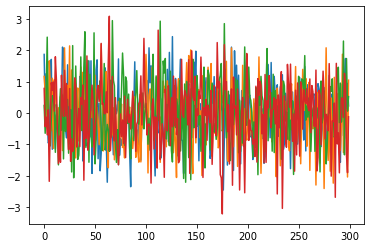

In [51]:
# random 100 observations
Y = np.random.randn(300, 4) 
plt.plot(Y)

In [52]:
# 0.05 measurement error in each outcome variable
sigma_measurement = np.full(4, 0.05)

sigma_measurement.shape

(4,)

In [53]:

# calculate log-likelihood
sj.estimation.log_likelihood(Y, Sigma, sigma_measurement)

%time sj.estimation.log_likelihood(Y, Sigma, sigma_measurement)

CPU times: user 80.5 ms, sys: 1.79 ms, total: 82.3 ms
Wall time: 21.2 ms


-156970.76780557015

### 5.3 Putting it together: calculating the likelihood in an example
Continue to consider the shock process from section 5.1, where $dZ$ had one persistent component and one transitory component. Imagine that we do not know the persistence parameter $\rho$ of the persistent component, nor do we know the *relative variances* of these two shocks or the variances of the measurement errors. Given some observed data $\mathbf{w}$ with 100 observations of $dZ, dY, dC, dY$, what does the log-likelihood as a function of these parameters look like, and how do we compute it?

We write the following function that essentially takes a vector of parameters to estimate $[\rho, \sigma_1,\sigma_2]$ taking as give two objects: an $n_o\times 1,\quad \sigma_\text{measurement error}$ and $T\times n_o Y = [dZ,dY,dC,dK]]$

In [54]:
def log_likelihood_from_parameters(rho, sigma_persist, sigma_trans, sigma_measurement, Y):
    # impulse response to persistent shock
    dZ1 = rho**(np.arange(T))
    dY1, dC1, dK1 = G['Y'] @ dZ1, G['C'] @ dZ1, G['K'] @ dZ1
    dX1 = np.stack([dZ1, dY1, dC1, dK1], axis=1)
    
    # since transitory shock does not depend on any unknown parameters,
    # except scale sigma_trans, we just reuse the dX2 already calculated earlier!
    
    # stack impulse responses together to make MA(T-1) representation 'M'
    M = np.stack([dX1, dX2], axis=2)
    
    # calculate all covariances
    Sigma = sj.estimation.all_covariances(M, np.array([sigma_persist, sigma_trans]))
    
    # calculate log=likelihood from this
    return sj.estimation.log_likelihood(Y, Sigma, sigma_measurement)

**Simulate sample data.** Now let's simulate more realistic series $w=\{dZ, dY, dC, dK\}$, assuming the *same parameters* as above, to see what evaluating the log-likelihood is like.

In [56]:
# stack covariances into matrix using helper function, then do a draw using NumPy routine
V = sj.estimation.build_full_covariance_matrix(Sigma, sigma_measurement, 300)
Y = np.random.multivariate_normal(np.zeros(300*4), V).reshape((300, 4))
print(V.shape,Y.shape)

(1200, 1200) (300, 4)


Now let's plot the log-likelihood of $w$ as a function of the standard deviation of the persistent component (the true value of which is 0.1), given correct values for all other parameters. Note that evaluating the log-likelihood 100 times takes well below one second.

In [57]:
sigma_persist_values = np.linspace(0.05, 0.2, 300)
%time lls = np.array([log_likelihood_from_parameters(rho, sigma_persist, sigma_trans, sigma_measurement, Y) for sigma_persist in sigma_persist_values])

CPU times: user 21.4 s, sys: 639 ms, total: 22.1 s
Wall time: 5.94 s


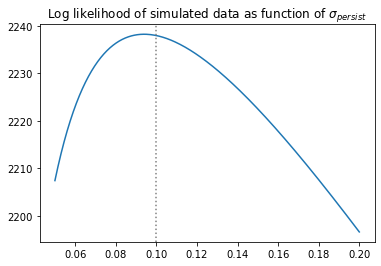

In [58]:
plt.plot(sigma_persist_values, lls)
plt.axvline(0.1, linestyle=':', color='gray')
plt.title(r'Log likelihood of simulated data as function of $\sigma_{persist}$')
plt.show()

Reassuringly, the mode is near (although not exactly at, since we're simulating a finite sample with only 100 periods) the value of $\sigma_{persist}=0.1$ with which the data was simulated!

<a id="7-nonlinear"></a>

## 7 Nonlinear perfect foresight dynamics
Linearized impulse responses are invariant to the sign and size of aggregate shocks by construction. Although this is not a problem for many applications, it is clearly a limitation. Here, we demonstrate that the Jacobian is also extremely useful in solving for nonlinear dynamics.

Consider the case of an economy that starts at the steady state, and receives an unexpected shock at date 0. This is often called an "MIT shock". 

For a given shock $Z$, the solution is still characterized by the $K$ that solves $H(K,Z)=0$. Our algorithm to find this $K$, a simple variant of Newton's method, iterates on a sequence of guesses $K^j$ for the path of capital as follows:
1. starting with $j=0$, guess a path $K^0$
2. calculate $H(K^j, Z)$
3. update the guess according to $$K^{j+1} = K^j - H_K(K_{ss}, Z_{ss})^{-1} H(K^j, Z)$$
and return to step 2 for $j+1$

The only difference between this and the standard Newton's method is that we use the Jacobian $H_K$ around the steady state (which we have already calculated), rather than the Jacobian around the current guess (which is somewhat more difficult to calculate). Still, this tends to achieve extremely fast convergence.

Although iterative methods to solve for equilibrium in response to MIT shocks are quite common in the heterogeneous-agent literature, these methods generally use ad-hoc rules for updating the guess, which can be fragile and slow. In applications with no or limited heterogeneity (such as spender-saver models) where it is possible to calculate Jacobians easily, Newton's method has been used to provide faster and more robust convergence -- see, for instance, [Juillard (1996)](http://www.cepremap.fr/depot/couv_orange/co9602.pdf).

But until now, this has not been applied to heterogeneous-agent models, since the Jacobian has been too difficult to calculate. The only partial applications to date, to our knowledge, are in [Auclert and Rognlie (2018)](http://web.stanford.edu/~aauclert/computational_appendix_inequad.pdf), which uses an auxiliary model to compute an approximate Jacobian, and in [Straub (2018)](https://scholar.harvard.edu/files/straub/files/jmp_straub_jan_2.pdf), which uses interpolation to compute an approximate Jacobian. In this paper, however, we have provided a highly efficient method to compute the *exact* Jacobian around the steady state for any heterogeneous-agent model, and can thus readily apply Newton's method.

### 7.1 Implementation

Our quasi-Newton method can be implemented in two steps. First, build the nonlinear function $H(U, Z).$ Second, guess $U$ for a given $Z$ and iterate until convergence. We automatized both of these, so all we need to do is call a single function, `nonlinear.td_solve`.

In [39]:
Z = ss['Z'] + 0.01*0.8**np.arange(T)

td_nonlin = sj.td_solve(ss=ss, block_list=[firm, household, mkt_clearing],
                        unknowns=['K'], targets=['asset_mkt'], H_U=H_K, monotonic=True, Z=Z)

On iteration 0
   max error for asset_mkt is 3.37E-02
On iteration 1
   max error for asset_mkt is 5.73E-05
On iteration 2
   max error for asset_mkt is 1.26E-07
On iteration 3
   max error for asset_mkt is 1.75E-10


We see that this is quite quick, taking only 3 iterations after the initial guess to achieve high accuracy -- far fewer than typical ad-hoc updating rules, which can take hundreds or even thousands of iterations.

Now let's compare to the results we'd get for the linearized impulse response, and plot the paths for the real interest rate $r$.

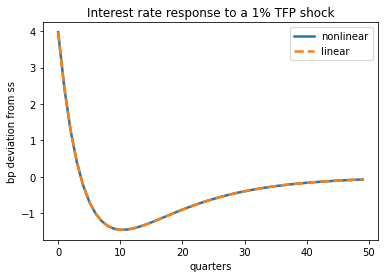

In [40]:
dr_nonlin = 10000 * (td_nonlin['r'] - ss['r'])
dr_lin = 10000 * G['r'] @ (Z - ss['Z'])

plt.plot(dr_nonlin[:50], label='nonlinear', linewidth=2.5)
plt.plot(dr_lin[:50], label='linear', linestyle='--', linewidth=2.5)
plt.title(r'Interest rate response to a 1% TFP shock')
plt.ylabel(r'bp deviation from ss')
plt.xlabel(r'quarters')
plt.legend()
plt.show()

There is no visible difference -- the first-order approximation is almost perfect here.

If we increase the size of the productivity shock on impact to 10% (enormous!), we can begin to see small nonlinearities kick in, and the solution requires five iterations rather than three:

On iteration 0
   max error for asset_mkt is 3.47E-01
On iteration 1
   max error for asset_mkt is 5.22E-03
On iteration 2
   max error for asset_mkt is 1.16E-04
On iteration 3
   max error for asset_mkt is 1.69E-06
On iteration 4
   max error for asset_mkt is 1.13E-08
On iteration 5
   max error for asset_mkt is 2.95E-10


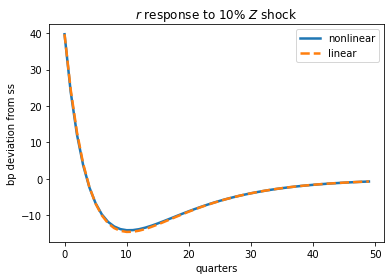

In [41]:
Z = ss['Z'] + 0.1*0.8**np.arange(T)

td_nonlin = sj.td_solve(ss, [firm, household, mkt_clearing], ['K'], ['asset_mkt'], H_K, monotonic=True, Z=Z)

# extract interest rate response, scale to basis points
dr_nonlin = 10000 * (td_nonlin['r'] - ss['r'])
dr_lin = 10000 * G['r'] @ (Z - ss['Z'])

plt.plot(dr_nonlin[:50], label='nonlinear', linewidth=2.5)
plt.plot(dr_lin[:50], label='linear', linestyle='--', linewidth=2.5)
plt.title(r'$r$ response to 10% $Z$ shock')
plt.ylabel(r'bp deviation from ss')
plt.xlabel(r'quarters')
plt.legend()
plt.show()